In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import glob
import pandas as pd 
import scipy as sp 
import scipy.stats as sps
import astropy
from astropy.io import fits
from scipy.stats import poisson
import statsmodels as sm
from scipy.special import gammaln
from matplotlib.ticker import MultipleLocator, AutoMinorLocator


# colors 
# special plot params
plt.style.use('dark_background')
plt.rcParams['axes.facecolor'] = 'midnightblue'
plt.rcParams['figure.facecolor'] = "#060552"
plt.rcParams['axes.grid'] = 'True'
plt.rcParams['grid.color'] = 'steelblue'
plt.rcParams['grid.linewidth'] = 0.6
plt.rcParams['grid.alpha'] = 0.8
plt.rcParams['axes.edgecolor'] = 'white'
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['legend.facecolor'] = "#060552"



In [2]:
# name files -- specifically the 
mean_061026_test1 = '/Users/leayamashiro/AnA_MSc/Observations/git/lapalma_analysis/analysis_LY/data_LY/our_data061026_norm_testing/full_mean/normalised/saving_mean_test_061026_norm.txt'

In [3]:
mean_spec = np.loadtxt(mean_061026_test1)
mean_spec

array([[6.40001708e+03, 1.00275461e+00],
       [6.40005036e+03, 1.00747349e+00],
       [6.40008364e+03, 1.01534182e+00],
       ...,
       [6.74990094e+03, 1.01506686e+00],
       [6.74993605e+03, 1.00830425e+00],
       [6.74997115e+03, 1.00966856e+00]], shape=(10238, 2))

Make sure it's a spectrum: 

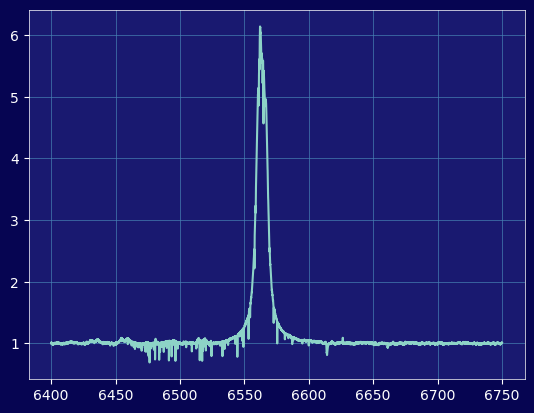

In [5]:
plt.plot(mean_spec[:,0], mean_spec[:,1])

figure out good cropping: 

In [10]:
%matplotlib qt

In [12]:
plt.plot(mean_spec[:,0], mean_spec[:,1], lw=0.5)

plt.xlim(6510, 6610)

(6510.0, 6610.0)

Now try to calculate EW: 

In [13]:
# 6528 = left 
# 6611 = right
import matplotlib.pyplot as plt

half_left = 6537.7
half_right = 6594

wl = mean_spec[:,0]
flux = mean_spec[:,1]

line_mask = (
    (wl >= half_left) &
    (wl <= half_right)
)

line_wave = wl[line_mask]
line_flux = flux[line_mask]

EW = np.trapezoid(
    1.0 - line_flux,
    line_wave
)
print(np.abs(EW))


56.01294269381089


In [ ]:
# function to bring in normalized spectra and then calculate EW 

def calculate_EW(median_spec, )

### now trying with the second normalization version 

In [21]:
%matplotlib qt
median2_np = np.loadtxt(median_2)
plt.plot(median2_np[:,0], median2_np[:,1], lw=0.5)

In [23]:
# 6535 = left 
# 6586 = right 

# set integration bounds of h-alpha (half)
h_alpha_left = 6535
h_alpha_right = 6586

wl = median2_np[:,0]
flux = median2_np[:,1]

line_mask = (
    (wl >= h_alpha_left) &
    (wl <= h_alpha_right)
)

line_wave = wl[line_mask]
line_flux = flux[line_mask]

EW = np.trapezoid(
    1.0 - line_flux,
    line_wave
)
print(np.abs(EW))

47.42502222773655


#### Okay so this is bad because me doing the normalization 2 separate times on the same spectra yielded a difference in EW of about 4 angstroms. No bueno!! I think the next thing is to not normalize by fitting a line but by fitting a polynomial of N degrees (like maybe 5 or 6 even). 